# Information asymétrique : types privés, antisélection et mécanismes

> **Navigation.** Ce notebook prolonge [GameTheory-11 — jeux bayésiens](GameTheory-11-BayesianGames.ipynb), [GameTheory-16 — design de mécanismes](GameTheory-16-MechanismDesign.ipynb) et leur formalisation bayésienne. Il réutilise le cadre de Harsanyi sans dupliquer ses définitions.

## Objectifs d’apprentissage

À la fin de ce notebook, vous saurez :

1. déterminer comment un prix modifie endogènement la composition d’un marché à qualité privée ;
2. vérifier les contraintes IC/IR d’un signal séparateur et lire graphiquement le single-crossing ;
3. distinguer équilibre actuariel type par type, équilibre concurrentiel et déviation de cream-skimming ;
4. simuler une réaction anticipée avec retrait puis recalcul des choix ;
5. séparer les résultats analytiques des observations obtenues sur une grille finie.

**Prérequis :** espérance conditionnelle, équilibre de Nash, utilité espérée et jeux bayésiens.  
**Durée indicative :** 90 minutes, exercices compris.

## 1. Une même maladie, quatre réponses institutionnelles

L’**antisélection** vient d’une information privée détenue *avant* l’échange ou la signature : la qualité, la productivité ou le risque ne sont pas observés symétriquement. Elle se distingue de l’**aléa moral**, qui porte sur une action privée *après* contrat et reste hors du modèle principal.

La question commune est compositionnelle : **comment un prix, un signal ou un contrat change-t-il l’ensemble des participants qui se sélectionnent eux-mêmes ?** Le parcours suit quatre réponses de plus en plus riches :

- **Akerlof** diagnostique l’effondrement possible d’un pool sous prix unique ;
- **Spence** laisse l’agent informé agir par un signal coûteux ;
- **Rothschild–Stiglitz** fait proposer un menu par le côté non informé ;
- **Wilson / Miyazaki / Spence** évalue une entrée après la réaction anticipée des contrats incumbents.

## 2. Harsanyi — types et croyances

Dans un jeu bayésien fini, un type privé $\theta\in\Theta$ est tiré selon un prior commun. Une stratégie de l’agent informé est contingente à son type ; après une observation, les croyances sont mises à jour lorsque l’événement observé a une probabilité positive. Les lettres $H/L$ changent de sens selon le modèle : qualité haute/basse chez Akerlof, productivité haute/basse chez Spence, risque haut/bas en assurance.

## 3. Outils et notations communs

| Symbole | Objet | Rôle dans les modèles |
|---|---|---|
| $\theta\in\Theta=\{L,H\}$ | type privé | qualité, productivité ou risque selon la section |
| $a\in A$ | action | choix générique contingent au type |
| $s\in S$ | signal | décision coûteuse observée dans Spence |
| $(q,p)\in Q\times\mathbb R$ | contrat | couverture $q$ et prime $p$ en assurance |
| $u(a,\theta)$ | utilité | évalue l’action ou le contrat pour le type $\theta$ |
| $c(\theta,s)$ | coût du signal | transforme le salaire en utilité $w(s)-c(\theta,s)$ |
| IC / IR | incitation / participation | auto-sélection et préférence au contrat extérieur |

La propriété de **single-crossing** ordonne les préférences par différences croissantes. Si $\theta_H>\theta_L$ et $a'>a$ :

$$u(a',\theta_H)-u(a,\theta_H)\ge u(a',\theta_L)-u(a,\theta_L).$$

Dans un modèle $u=w-c$, la même idée devient un coût incrémental plus faible pour le type haut :

$$c(\theta_H,s')-c(\theta_H,s)\le c(\theta_L,s')-c(\theta_L,s),\qquad s'>s.$$

Cette propriété concerne les différences d’utilité ou de coût marginal ; elle ne doit pas être confondue avec un ratio de vraisemblance monotone. Akerlof reste ici **price-only** : aucun menu, signal ou single-crossing n’y est supposé.

## 4. Carte descriptive des modèles

| Modèle | Information privée | Instrument | Objet d’équilibre étudié ici |
|---|---|---|---|
| Akerlof (1970) | qualité du vendeur | prix unique | point fixe de participation |
| Spence (1973) | productivité du candidat | signal coûteux | paire séparatrice sous IC/IR |
| Rothschild–Stiglitz (1976) | probabilité de sinistre | contrats concurrents | Nash entre assureurs sur un domaine fini |
| Wilson / Miyazaki / Spence | risque privé | menu anticipatif fini | stabilité sous la règle de retrait codée |

> **Frontière de validité.** Les calculs RS et Wilson/MWS portent sur des domaines finis et une utilité CARA paramétrée. Ils rendent les mécanismes falsifiables, mais ne constituent ni une preuve d’existence ni une preuve d’unicité générale.

> **Ancres savantes.** Akerlof (1970), *The Quarterly Journal of Economics*, 84(3), 488–500 ; Spence (1973), *The Quarterly Journal of Economics*, 87(3), 355–374 ; Rothschild et Stiglitz (1976), *The Quarterly Journal of Economics*, 90(4), 629–649 ; Wilson (1977), *The Bell Journal of Economics*, 8(1), 167–207 ; Miyazaki (1977), *The Bell Journal of Economics*, 8(2), 394–418.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from math import exp, isclose

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
print("Environnement prêt : NumPy, pandas, Matplotlib et outils de menus finis chargés")

Environnement prêt : NumPy, pandas, Matplotlib et outils de menus finis chargés


## Akerlof : un point fixe de participation à prix unique

Le vendeur observe la qualité $q\in\{L,H\}$. À un prix candidat $P$, les vendeurs participants forment

$$S(P)=\{q\mid c_q\le P\}.$$

Lorsque cet ensemble est non vide, l’acheteur accepte si

$$P\le \mathbb E[v(q)\mid q\in S(P)].$$

Le prix doit donc être compatible simultanément avec la participation des vendeurs et la disposition à payer de l’acheteur. Pour faire participer les deux qualités, il faut $P\ge c_H$ et $P\le \pi v_H+(1-\pi)v_L$. Si $v_H>v_L$, le pooling devient donc possible lorsque

$$\pi\ge\pi_{min}=\frac{c_H-v_L}{v_H-v_L}.$$

Ce seuil vaut uniquement pour le modèle fini défini ici.

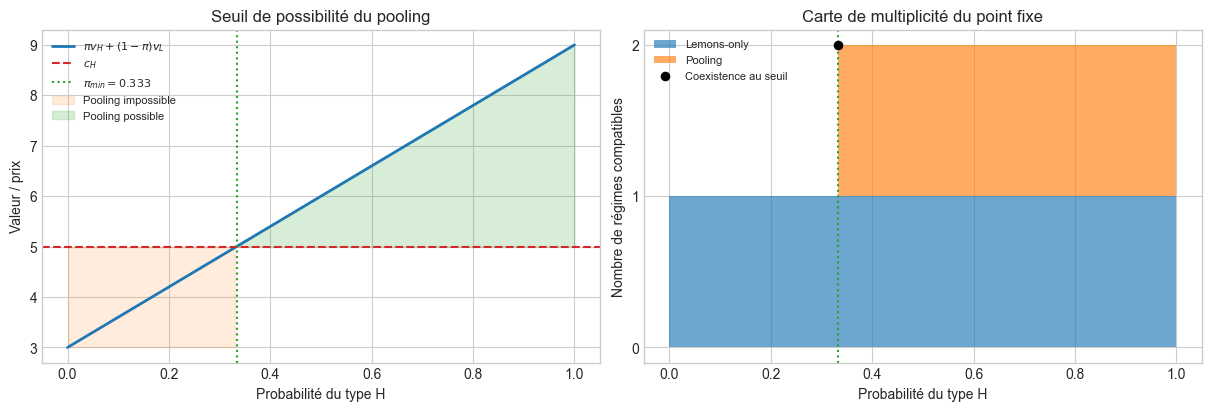

Seuil analytique : pi_min = 0.333


,scenario,pi,regime,participants,price_lower,price_upper,upper_closed,conditional_value
0,faible part de H,0.200000,lemons_only,"(L,)",1.0,3.0,True,3.0
1,seuil exact,0.333333,lemons_only,"(L,)",1.0,3.0,True,3.0
2,seuil exact,0.333333,pooling,"(L, H)",5.0,5.0,True,5.0
3,forte part de H,0.500000,lemons_only,"(L,)",1.0,3.0,True,3.0
4,forte part de H,0.500000,pooling,"(L, H)",5.0,6.0,True,6.0
5,aucun échange,0.500000,no_trade,(),NaN,NaN,NaN,NaN


In [2]:
def akerlof_equilibria(
    pi: float,
    c_low: float,
    c_high: float,
    v_low: float,
    v_high: float,
) -> list[dict[str, object]]:
    """Énumère tous les intervalles de prix compatibles avec le point fixe."""
    if not 0.0 <= pi <= 1.0:
        raise ValueError("pi doit appartenir à [0, 1]")
    if not c_low < c_high:
        raise ValueError("Le modèle suppose c_low < c_high")
    if not v_low < v_high:
        raise ValueError("Le modèle suppose v_low < v_high")

    equilibria: list[dict[str, object]] = []
    lemons_upper = min(c_high, v_low)
    if c_low <= lemons_upper:
        equilibria.append({
            "regime": "lemons_only",
            "participants": ("L",),
            "price_lower": c_low,
            "price_upper": lemons_upper,
            "upper_closed": v_low < c_high,
            "conditional_value": v_low,
        })

    pooling_value = pi * v_high + (1.0 - pi) * v_low
    if c_high <= pooling_value:
        equilibria.append({
            "regime": "pooling",
            "participants": ("L", "H"),
            "price_lower": c_high,
            "price_upper": pooling_value,
            "upper_closed": True,
            "conditional_value": pooling_value,
        })

    if not equilibria:
        return [{"regime": "no_trade", "participants": ()}]
    return equilibria


scenarios = [
    {"scenario": "faible part de H", "pi": 0.20, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "seuil exact", "pi": 1 / 3, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "forte part de H", "pi": 0.50, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "aucun échange", "pi": 0.50, "c_low": 4, "c_high": 7, "v_low": 3, "v_high": 6},
]
rows = []
for scenario in scenarios:
    parameters = {key: value for key, value in scenario.items() if key != "scenario"}
    for equilibrium in akerlof_equilibria(**parameters):
        rows.append({"scenario": scenario["scenario"], "pi": scenario["pi"], **equilibrium})
akerlof_results = pd.DataFrame(rows)

pi_values = np.linspace(0, 1, 201)
pooling_values = pi_values * 9 + (1 - pi_values) * 3
pi_min = (5 - 3) / (9 - 3)
regime_map = pd.DataFrame({
    "pi": pi_values,
    "lemons_only": [
        any(item["regime"] == "lemons_only" for item in akerlof_equilibria(pi, 1, 5, 3, 9))
        for pi in pi_values
    ],
    "pooling": [
        any(item["regime"] == "pooling" for item in akerlof_equilibria(pi, 1, 5, 3, 9))
        for pi in pi_values
    ],
})
regime_map["nombre_regimes"] = regime_map[["lemons_only", "pooling"]].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(pi_values, pooling_values, linewidth=2, label=r"$\pi v_H+(1-\pi)v_L$")
axes[0].axhline(5, color="tab:red", linestyle="--", label=r"$c_H$")
axes[0].axvline(pi_min, color="tab:green", linestyle=":", label=fr"$\pi_{{min}}={pi_min:.3f}$")
axes[0].fill_between(pi_values, 3, 5, where=pi_values < pi_min, color="tab:orange", alpha=0.14, label="Pooling impossible")
axes[0].fill_between(pi_values, 5, pooling_values, where=pooling_values >= 5, color="tab:green", alpha=0.18, label="Pooling possible")
axes[0].set(xlabel="Probabilité du type H", ylabel="Valeur / prix", title="Seuil de possibilité du pooling")
axes[0].legend(fontsize=8)

axes[1].fill_between(pi_values, 0, regime_map["lemons_only"].astype(int), step="mid", alpha=0.65, label="Lemons-only")
axes[1].fill_between(pi_values, regime_map["lemons_only"].astype(int), regime_map["nombre_regimes"], step="mid", alpha=0.65, label="Pooling")
axes[1].axvline(pi_min, color="tab:green", linestyle=":")
axes[1].scatter([pi_min], [2], color="black", s=35, zorder=3, label="Coexistence au seuil")
axes[1].set(xlabel="Probabilité du type H", ylabel="Nombre de régimes compatibles", yticks=[0, 1, 2], title="Carte de multiplicité du point fixe")
axes[1].legend(fontsize=8)
plt.show()

print(f"Seuil analytique : pi_min = {pi_min:.3f}")
akerlof_results

### Lecture du résultat

Le panneau gauche sépare deux propositions différentes. Sous $\pi_{min}=1/3$, la valeur moyenne du pool reste sous $c_H=5$ : aucun prix ne peut simultanément faire participer le type H et être accepté par l’acheteur. Au-dessus, un intervalle pooling devient **compatible**, mais « possible » ne veut pas dire « uniquement sélectionné ».

Le panneau droit rend cette nuance visible : `lemons_only` reste compatible sur toute la grille de $\pi$, tandis que `pooling` s’ajoute à partir du seuil. Au seuil exact, sa borne inférieure et sa borne supérieure coïncident en $P=c_H=5$ : c’est un équilibre singleton qui coexiste avec lemons-only. La multiplicité vient donc du point fixe de participation, pas d’une erreur de classification.

> **À retenir.** Akerlof décrit ici une maladie de composition : le prix modifie les qualités présentes, lesquelles modifient à leur tour la disposition à payer. Une condition de possibilité du pooling n’est pas un critère de sélection parmi plusieurs équilibres.

## Exercice 1 — classer les régimes

À partir du tableau précédent, compléter la fonction pour associer à chaque scénario l’ensemble de ses régimes. Vérifier en particulier que le scénario au seuil admet deux régimes, tandis que le dernier conduit à `no_trade`.

**Indice :** grouper les lignes par `scenario`, puis convertir la colonne `regime` en ensemble.

In [3]:
def exercice_classer_regimes() -> dict[str, set[str]] | None:
    # TODO étudiant : grouper akerlof_results par scénario et collecter les régimes.
    return None


print("Classification à compléter :", exercice_classer_regimes())

Classification à compléter : None


## Exercice 2 — retrouver le seuil graphiquement

Compléter la fonction pour retourner le premier prior de la grille `pi_values` tel que la valeur du pooling atteint `c_high = 5`. Comparer ce résultat numérique à la formule analytique de $\pi_{min}$.

**Indice :** utiliser un masque booléen sur `pooling_values`, puis sélectionner son premier indice vrai.

In [4]:
def exercice_seuil_numerique() -> float | None:
    # TODO étudiant : trouver le premier pi tel que pooling_values >= 5.
    return None


print("Seuil numérique à compléter :", exercice_seuil_numerique())

Seuil numérique à compléter : None


## Exercice 3 — frontière d’Akerlof

Compléter la fonction suivante pour détecter si l’intervalle pooling se réduit à un prix unique au seuil $\pi_{min}$. Vérifier ensuite que `lemons_only` et `pooling` peuvent tous deux apparaître dans la liste retournée.

**Étape 1 :** appeler `akerlof_equilibria` au seuil.  
**Étape 2 :** isoler le régime `pooling`.  
**Étape 3 :** comparer ses bornes inférieure et supérieure.

In [5]:
def exercice_pooling_singleton() -> bool | None:
    # TODO étudiant : appeler akerlof_equilibria au seuil et comparer les bornes.
    return None


print("Résultat à compléter :", exercice_pooling_singleton())


Résultat à compléter : None


## Spence : signal coûteux et contraintes d’incitation

Deux types de productivité $y_H>y_L$ choisissent un signal $s$. En séparation concurrentielle, $w(s_q)=y_q$ et l’utilité du candidat est

$$u(q,s)=w(s)-c(q,s).$$

Pour une paire séparatrice $(s_L,s_H)$, les quatre contraintes sont :

| Contrainte | Inégalité |
|---|---|
| $IC_H$ | $y_H-c(H,s_H)\ge y_L-c(H,s_L)$ |
| $IC_L$ | $y_L-c(L,s_L)\ge y_H-c(L,s_H)$ |
| $IR_H$ | $y_H-c(H,s_H)\ge \bar u_H$ |
| $IR_L$ | $y_L-c(L,s_L)\ge \bar u_L$ |

Avec $s_L=0$ et $c(q,s)=s/q$, les deux IC donnent

$$q_L(y_H-y_L)\le s_H\le q_H(y_H-y_L).$$

Les IR peuvent resserrer cet intervalle. Le séparateur de Riley est le plus petit $s_H$ qui dissuade le type bas tout en respectant la participation du type haut. Rien n’impose une rente informationnelle nulle.

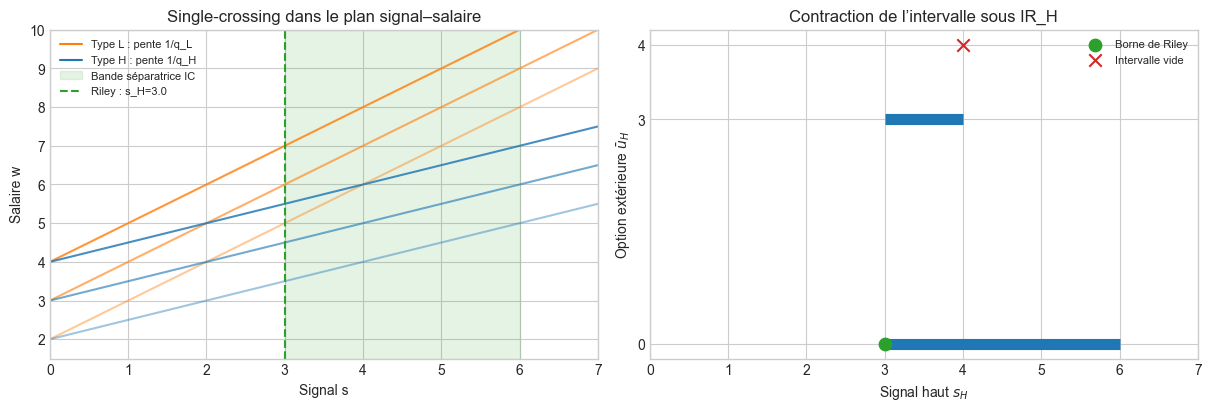

Intervalle IC sans IR contraignante : [3.0, 6.0]
Vérification au séparateur de Riley :


,contrainte,membre_gauche,membre_droit,respectee
0,IC_H,3.5,2.0,True
1,IC_L,2.0,2.0,True
2,IR_H,3.5,0.0,True
3,IR_L,2.0,1.0,True


,option_exterieure_H,signal_low,signal_high_lower,signal_high_upper,riley_signal_high,intervalle
0,0.0,0.0,3.0,6.0,3.0,NaN
1,3.0,0.0,3.0,4.0,3.0,NaN
2,4.0,NaN,NaN,NaN,NaN,vide


In [6]:
def spence_separating_interval(
    y_low: float,
    y_high: float,
    q_low: float,
    q_high: float,
    reserve_low: float = 0.0,
    reserve_high: float = 0.0,
) -> dict[str, float] | None:
    """Calcule l’intervalle séparateur pour c(q,s)=s/q et s_low=0."""
    if not y_low < y_high:
        raise ValueError("Le modèle suppose y_low < y_high")
    if not 0.0 < q_low < q_high:
        raise ValueError("Le modèle suppose 0 < q_low < q_high")
    if y_low < reserve_low:
        return None

    productivity_gap = y_high - y_low
    lower = max(0.0, q_low * productivity_gap)
    upper = min(q_high * productivity_gap, q_high * (y_high - reserve_high))
    if lower > upper and not isclose(lower, upper):
        return None
    return {
        "signal_low": 0.0,
        "signal_high_lower": lower,
        "signal_high_upper": upper,
        "riley_signal_high": lower,
    }


spence_rows = []
for reserve_high in (0.0, 3.0, 4.0):
    interval = spence_separating_interval(2, 5, 1, 2, reserve_low=1, reserve_high=reserve_high)
    spence_rows.append({"option_exterieure_H": reserve_high, **(interval or {"intervalle": "vide"})})
spence_results = pd.DataFrame(spence_rows)

interval = spence_separating_interval(2, 5, 1, 2, reserve_low=1, reserve_high=0)
assert interval is not None
lower = interval["signal_high_lower"]
upper = interval["signal_high_upper"]
signal_values = np.linspace(0, 7, 250)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for utility_level, alpha in ((2.0, 0.42), (3.0, 0.62), (4.0, 0.82)):
    axes[0].plot(signal_values, utility_level + signal_values / 1.0, color="tab:orange", alpha=alpha)
    axes[0].plot(signal_values, utility_level + signal_values / 2.0, color="tab:blue", alpha=alpha)
axes[0].plot([], [], color="tab:orange", label="Type L : pente 1/q_L")
axes[0].plot([], [], color="tab:blue", label="Type H : pente 1/q_H")
axes[0].axvspan(lower, upper, color="tab:green", alpha=0.12, label="Bande séparatrice IC")
axes[0].axvline(lower, color="tab:green", linestyle="--", label=f"Riley : s_H={lower:.1f}")
axes[0].set(xlabel="Signal s", ylabel="Salaire w", title="Single-crossing dans le plan signal–salaire", xlim=(0, 7), ylim=(1.5, 10))
axes[0].legend(fontsize=8)

valid_rows = spence_results[spence_results["intervalle"].isna() if "intervalle" in spence_results else np.ones(len(spence_results), dtype=bool)]
for _, row in valid_rows.iterrows():
    axes[1].hlines(row["option_exterieure_H"], row["signal_high_lower"], row["signal_high_upper"], linewidth=8, color="tab:blue")
axes[1].scatter([lower], [0], color="tab:green", s=80, zorder=3, label="Borne de Riley")
axes[1].scatter([4], [4], marker="x", color="tab:red", s=80, label="Intervalle vide")
axes[1].set(xlabel=r"Signal haut $s_H$", ylabel=r"Option extérieure $\bar u_H$", title="Contraction de l’intervalle sous IR_H", xlim=(0, 7), yticks=[0, 3, 4])
axes[1].legend(fontsize=8)
plt.show()

ic_ir_at_riley = pd.DataFrame([
    {"contrainte": "IC_H", "membre_gauche": 5 - lower / 2, "membre_droit": 2 - 0 / 2},
    {"contrainte": "IC_L", "membre_gauche": 2 - 0 / 1, "membre_droit": 5 - lower / 1},
    {"contrainte": "IR_H", "membre_gauche": 5 - lower / 2, "membre_droit": 0},
    {"contrainte": "IR_L", "membre_gauche": 2 - 0 / 1, "membre_droit": 1},
])
ic_ir_at_riley["respectee"] = ic_ir_at_riley["membre_gauche"] >= ic_ir_at_riley["membre_droit"] - 1e-9
print(f"Intervalle IC sans IR contraignante : [{lower:.1f}, {upper:.1f}]")
print("Vérification au séparateur de Riley :")
display(ic_ir_at_riley)
spence_results

### Lecture du résultat

Le panneau gauche matérialise le single-crossing : pour conserver une même utilité lorsque le signal augmente, le salaire du type L doit croître deux fois plus vite que celui du type H. Cette différence de pentes ouvre la bande $[3,6]$ dans laquelle H accepte de se distinguer tandis que L refuse de l’imiter.

À la borne basse $s_H=3$, la table IC/IR confirme les quatre inégalités. Riley sélectionne cette borne parce qu’elle est le signal **le moins coûteux parmi ceux qui dissuadent L** ; cette sélection ne signifie pas que la rente de H est universellement nulle. Le panneau droit montre en outre que l’option extérieure de H resserre la borne supérieure : pour $\bar u_H=4$, IR_H rend l’intervalle vide.

> **Distinction utile.** Le single-crossing est ici une propriété des différences de coûts du signal. Une propriété de ratio de vraisemblance monotone porterait sur une famille de distributions observées ; elle n’est ni utilisée ni nécessaire dans ce calcul.

### Exercices 4 et 5 — Spence

**Exercice 4.** Compléter la fonction pour faire varier l’option extérieure du type haut et retourner les bornes de l’intervalle séparateur.  
**Indice :** appeler `spence_separating_interval` pour chaque valeur de `reserve_high`.

**Exercice 5.** Vérifier numériquement les quatre contraintes IC/IR pour un signal haut candidat.  
**Indice :** calculer séparément les utilités des deux types sous vérité et imitation.

In [7]:
def exercice_option_exterieure_spence() -> pd.DataFrame | None:
    # TODO étudiant : faire varier reserve_high et collecter les intervalles.
    return None


def exercice_verifier_ic_ir(signal_high: float) -> dict[str, bool] | None:
    # TODO étudiant : évaluer séparément IC_H, IC_L, IR_H et IR_L.
    return None


print(
    "Exercices Spence à compléter :",
    exercice_option_exterieure_spence(),
    exercice_verifier_ic_ir(3.0),
)

Exercices Spence à compléter : None None


## Rothschild–Stiglitz : screening concurrentiel fini

Un contrat $C=(\alpha,\beta)$ fixe une couverture $\alpha\in[0,1]$ et une prime $\beta$. La convention est explicite : $p_H>p_L$, donc `H` est le haut risque. Avec une perte $D$, le profit attendu de l’assureur pour un type $p$ est

$$\Pi(C,p)=\beta-p\alpha D.$$

La frontière actuariellement équitable est définie **type par type** par $\beta=p\alpha D$. Elle ne constitue pas une subvention croisée. Dans le concept de Rothschild–Stiglitz, un menu candidat est un Nash entre assureurs seulement si aucune déviation unilatérale n’attire un sous-ensemble de types avec profit conditionnel positif. La non-existence est donc conditionnelle à une déviation cream-skimming effectivement trouvée sur la grille finie.

Déviations profitables : 319 ; cream-skimming L seul : 176
Meilleure déviation L seul : couverture=0.90, prime=2.15, profit=1.430


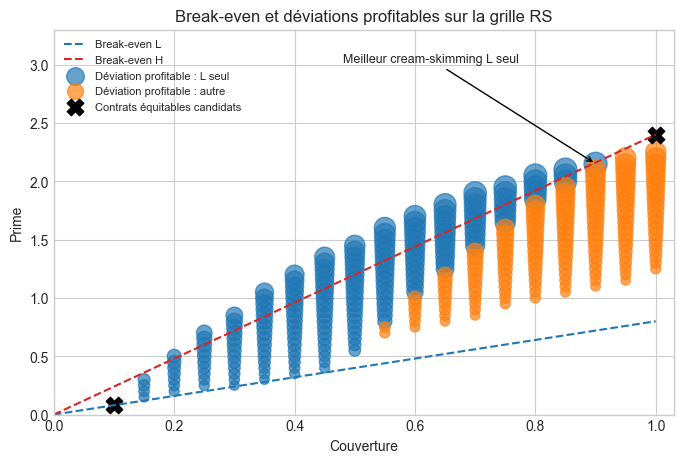

,couverture,prime,attire_L,attire_H,profit_conditionnel
0,0.15,0.15,True,False,0.03
1,0.15,0.20,True,False,0.08
2,0.15,0.25,True,False,0.13
3,0.15,0.30,True,False,0.18
4,0.20,0.20,True,False,0.04
5,0.20,0.25,True,False,0.09
6,0.20,0.30,True,False,0.14
7,0.20,0.35,True,False,0.19
8,0.20,0.40,True,False,0.24
9,0.20,0.45,True,False,0.29


In [8]:
@dataclass(frozen=True)
class Contract:
    coverage: float
    premium: float


def expected_utility(
    contract: Contract,
    loss_probability: float,
    wealth: float = 10.0,
    loss: float = 8.0,
    risk_aversion: float = 0.35,
) -> float:
    """Calcule l’utilité CARA espérée d’un type assuré."""
    if not 0.0 <= loss_probability <= 1.0:
        raise ValueError("loss_probability doit appartenir à [0, 1]")
    if not 0.0 <= contract.coverage <= 1.0:
        raise ValueError("coverage doit appartenir à [0, 1]")
    wealth_no_loss = wealth - contract.premium
    wealth_with_loss = wealth - contract.premium - (1.0 - contract.coverage) * loss
    utility = lambda value: -exp(-risk_aversion * value)
    return (
        (1.0 - loss_probability) * utility(wealth_no_loss)
        + loss_probability * utility(wealth_with_loss)
    )


def expected_profit(contract: Contract, loss_probability: float, loss: float = 8.0) -> float:
    """Calcule le profit attendu de l’assureur pour un type."""
    return contract.premium - loss_probability * contract.coverage * loss


def chosen_contract(menu: tuple[Contract, ...], loss_probability: float) -> Contract:
    """Retourne le contrat préféré, option extérieure comprise."""
    outside = Contract(coverage=0.0, premium=0.0)
    return max((outside, *menu), key=lambda contract: expected_utility(contract, loss_probability))


def menu_outcome(
    menu: tuple[Contract, ...], pi_high: float, p_low: float, p_high: float
) -> dict[str, object]:
    """Évalue les choix et le profit agrégé d’un menu à deux types."""
    if not 0.0 <= pi_high <= 1.0:
        raise ValueError("pi_high doit appartenir à [0, 1]")
    if not 0.0 < p_low < p_high < 1.0:
        raise ValueError("Le modèle suppose 0 < p_low < p_high < 1")
    low_choice = chosen_contract(menu, p_low)
    high_choice = chosen_contract(menu, p_high)
    low_profit = expected_profit(low_choice, p_low)
    high_profit = expected_profit(high_choice, p_high)
    return {
        "low_choice": low_choice,
        "high_choice": high_choice,
        "low_profit": low_profit,
        "high_profit": high_profit,
        "aggregate_profit": (1.0 - pi_high) * low_profit + pi_high * high_profit,
        "cross_subsidy": low_profit * high_profit < 0.0,
    }


def rs_profitable_deviations(
    incumbent_menu: tuple[Contract, ...],
    candidate_contracts: tuple[Contract, ...],
    pi_high: float,
    p_low: float,
    p_high: float,
    tolerance: float = 1e-9,
) -> list[dict[str, object]]:
    """Énumère les déviations profitables sur les types qu’elles attirent."""
    incumbent = menu_outcome(incumbent_menu, pi_high, p_low, p_high)
    incumbent_low_u = expected_utility(incumbent["low_choice"], p_low)
    incumbent_high_u = expected_utility(incumbent["high_choice"], p_high)
    deviations: list[dict[str, object]] = []

    for contract in candidate_contracts:
        attracts_low = expected_utility(contract, p_low) > incumbent_low_u + tolerance
        attracts_high = expected_utility(contract, p_high) > incumbent_high_u + tolerance
        mass = (1.0 - pi_high) * attracts_low + pi_high * attracts_high
        if mass <= 0.0:
            continue
        weighted_profit = (
            (1.0 - pi_high) * attracts_low * expected_profit(contract, p_low)
            + pi_high * attracts_high * expected_profit(contract, p_high)
        )
        conditional_profit = weighted_profit / mass
        if conditional_profit > tolerance:
            deviations.append({
                "contract": contract,
                "attracts_low": attracts_low,
                "attracts_high": attracts_high,
                "conditional_profit": conditional_profit,
            })
    return deviations


p_low, p_high, pi_high = 0.10, 0.30, 0.25
fair_low = Contract(coverage=0.10, premium=p_low * 0.10 * 8.0)
fair_high = Contract(coverage=1.00, premium=p_high * 1.00 * 8.0)
assert isclose(expected_profit(fair_low, p_low), 0.0)
assert isclose(expected_profit(fair_high, p_high), 0.0)
contract_grid = tuple(
    Contract(coverage=coverage, premium=premium)
    for coverage in np.linspace(0.05, 1.00, 20)
    for premium in np.linspace(0.05, 3.20, 64)
)
deviations = rs_profitable_deviations(
    (fair_low, fair_high), contract_grid, pi_high, p_low, p_high
)
assert deviations, "La grille doit exhiber une déviation profitable."
deviation_frame = pd.DataFrame([
    {
        "couverture": item["contract"].coverage,
        "prime": item["contract"].premium,
        "attire_L": item["attracts_low"],
        "attire_H": item["attracts_high"],
        "profit_conditionnel": item["conditional_profit"],
    }
    for item in deviations
])
low_only = deviation_frame[deviation_frame["attire_L"] & ~deviation_frame["attire_H"]]
best_low_only = low_only.sort_values("profit_conditionnel", ascending=False).iloc[0]
print(
    f"Déviations profitables : {len(deviation_frame)} ; "
    f"cream-skimming L seul : {len(low_only)}"
)
print(
    "Meilleure déviation L seul : "
    f"couverture={best_low_only['couverture']:.2f}, "
    f"prime={best_low_only['prime']:.2f}, "
    f"profit={best_low_only['profit_conditionnel']:.3f}"
)

fig, ax = plt.subplots(figsize=(8, 5))
coverage_line = np.linspace(0, 1, 200)
ax.plot(coverage_line, p_low * coverage_line * 8, color="tab:blue", linestyle="--", label="Break-even L")
ax.plot(coverage_line, p_high * coverage_line * 8, color="tab:red", linestyle="--", label="Break-even H")
for target, group in deviation_frame.assign(
    cible=np.where(deviation_frame["attire_L"] & ~deviation_frame["attire_H"], "L seul", "autre")
).groupby("cible"):
    ax.scatter(
        group["couverture"],
        group["prime"],
        s=45 + 160 * group["profit_conditionnel"],
        label=f"Déviation profitable : {target}",
        alpha=0.68,
    )
ax.scatter(
    [fair_low.coverage, fair_high.coverage],
    [fair_low.premium, fair_high.premium],
    marker="X",
    s=140,
    color="black",
    label="Contrats équitables candidats",
)
ax.annotate(
    "Meilleur cream-skimming L seul",
    xy=(best_low_only["couverture"], best_low_only["prime"]),
    xytext=(0.48, 3.02),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=9,
)
ax.set(xlabel="Couverture", ylabel="Prime", title="Break-even et déviations profitables sur la grille RS", xlim=(0, 1.03), ylim=(0, 3.3))
ax.legend(fontsize=8, loc="upper left")
plt.show()
deviation_frame.head(10)

### Lecture du résultat

Les deux lignes pointillées sont des contraintes comptables distinctes : la pente du break-even H est plus forte parce que $p_H=0{,}30>p_L=0{,}10$. Les croix noires sont donc équitables **pour leur type respectif**, mais le profit nul type par type ne suffit pas à former un équilibre de Nash entre assureurs.

La cellule imprime le nombre total de déviations rentables et le sous-ensemble qui attire uniquement L. Le nuage montre où elles se situent dans l’espace couverture–prime ; la taille des points encode le profit conditionnel et l’annotation isole la meilleure déviation L-only de la grille. Ce contrat retire les bas risques du menu candidat : c’est le cream-skimming.

Le verdict est volontairement borné. Nous avons exhibé une déviation profitable pour cette grille, cette utilité CARA et ces paramètres ; nous n’avons pas démontré un théorème de non-existence sur le continuum des contrats. Le raisonnement complet distingue successivement **break-even**, **préférences des types**, **profit de la déviation**, puis **verdict d’équilibre**.

### Exercices 6 et 7 — Rothschild–Stiglitz

**Exercice 6.** Construire la frontière actuariellement équitable pour chaque type et vérifier le profit nul type par type.  
**Exercice 7.** Filtrer `deviation_frame` pour isoler les déviations qui attirent uniquement `L`, puis classer les cinq plus profitables.

Les deux exercices gardent distincts le break-even RS et une éventuelle subvention croisée au niveau d’un menu anticipatif.

In [9]:
def exercice_frontieres_equitables() -> pd.DataFrame | None:
    # TODO étudiant : générer les primes break-even pour p_low et p_high.
    return None


def exercice_cream_skimming() -> pd.DataFrame | None:
    # TODO étudiant : filtrer puis trier les déviations qui attirent L seul.
    return None


print(
    "Exercices RS à compléter :",
    exercice_frontieres_equitables(),
    exercice_cream_skimming(),
)

Exercices RS à compléter : None None


## Wilson / Miyazaki / Spence : règle anticipative bornée

Nous fixons maintenant une définition computationnelle complète, sans lui attribuer une portée générale :

1. l’ensemble admissible est une grille finie de contrats ;
2. chaque type choisit son utilité CARA maximale, option extérieure comprise ;
3. le profit d’un menu est la moyenne pondérée des profits sur les contrats choisis ;
4. après l’entrée d’un nouveau contrat, tout contrat **incumbent choisi mais déficitaire** est retiré ;
5. les choix sont recalculés jusqu’au point fixe de retrait ;
6. une déviation est profitable si le profit final de l’entrant est positif ;
7. un menu est retenu s’il est faisable en profit agrégé et n’admet aucune telle déviation sur la grille.

Une subvention croisée est possible au niveau du menu lorsqu’un type génère un profit positif et l’autre un profit négatif, avec profit agrégé non négatif. L’énumération peut produire zéro, un ou plusieurs menus ; aucun résultat d’existence ou d’unicité n’est supposé.

Menus anticipatifs retenus : 9 sur une grille finie de 12 contrats
Exemple avant/après : 2 retrait(s), profit final entrant=1.000


,tour,contrats_offerts,choix_L,choix_H,retraits
0,0,3,"(0.75, 0.4)","(0.75, 0.4)","[(0.75, 0.4)]"
1,1,2,"(0.5, 0.4)","(0.5, 0.4)","[(0.5, 0.4)]"
2,2,1,"(0.5, 1.6)","(0.5, 1.6)",[]


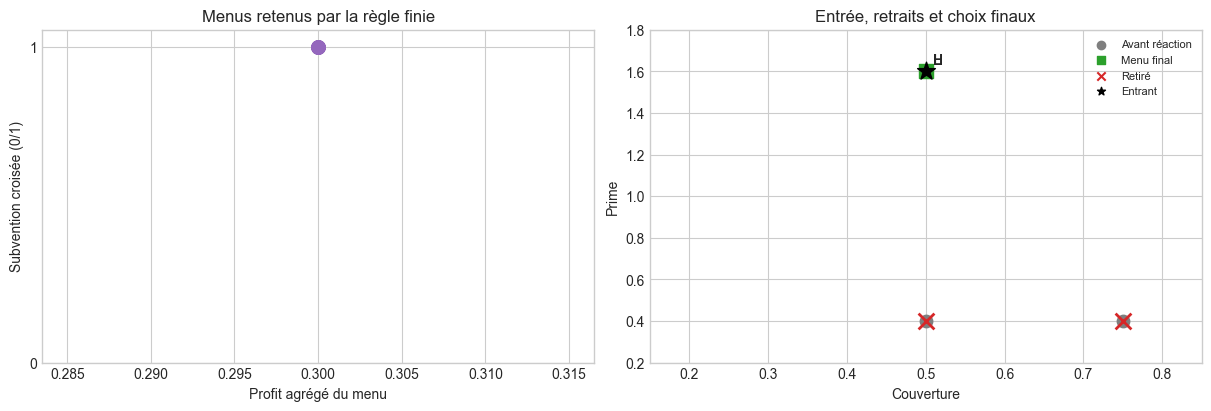

,menu,choix_L,choix_H,profit_agrege,subvention_croisee
0,"[(0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
1,"[(0.25, 0.4), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
2,"[(0.25, 0.8), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
3,"[(0.25, 1.2), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
4,"[(0.25, 1.6), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
5,"[(0.5, 0.8), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
6,"[(0.5, 1.2), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
7,"[(0.5, 1.6), (0.75, 1.2)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True
8,"[(0.75, 1.2), (0.75, 1.6)]","(0.75, 1.2)","(0.75, 1.2)",0.3,True


In [10]:
def anticipatory_deviation(
    incumbent_menu: tuple[Contract, ...],
    entrant: Contract,
    pi_high: float,
    p_low: float,
    p_high: float,
    tolerance: float = 1e-9,
) -> dict[str, object]:
    """Applique le point fixe fini de retrait à une déviation."""
    active_incumbents = list(incumbent_menu)
    withdrawn: list[Contract] = []
    type_data = ((1.0 - pi_high, p_low), (pi_high, p_high))
    initial_menu = tuple(active_incumbents) + (entrant,)
    initial_choices = tuple(
        chosen_contract(initial_menu, probability) for _, probability in type_data
    )
    trace: list[dict[str, object]] = []

    while True:
        available = tuple(active_incumbents) + (entrant,)
        choices = [chosen_contract(available, probability) for _, probability in type_data]
        newly_withdrawn = []
        for contract in active_incumbents:
            contract_profit = sum(
                mass * expected_profit(contract, probability)
                for (mass, probability), choice in zip(type_data, choices)
                if choice == contract
            )
            if contract in choices and contract_profit < -tolerance:
                newly_withdrawn.append(contract)
        trace.append({
            "tour": len(trace),
            "menu_actif": available,
            "choix": tuple(choices),
            "retraits": tuple(newly_withdrawn),
        })
        if not newly_withdrawn:
            break
        withdrawn.extend(newly_withdrawn)
        active_incumbents = [
            contract for contract in active_incumbents if contract not in newly_withdrawn
        ]

    final_menu = tuple(active_incumbents) + (entrant,)
    final_choices = tuple(
        chosen_contract(final_menu, probability) for _, probability in type_data
    )
    entrant_profit = sum(
        mass * expected_profit(entrant, probability)
        for (mass, probability), choice in zip(type_data, final_choices)
        if choice == entrant
    )
    return {
        "entrant": entrant,
        "initial_menu": initial_menu,
        "initial_choices": initial_choices,
        "withdrawn": tuple(withdrawn),
        "final_menu": final_menu,
        "final_choices": final_choices,
        "trace": tuple(trace),
        "entrant_profit": entrant_profit,
        "profitable": entrant_profit > tolerance,
    }


def anticipatory_menus(
    contracts: tuple[Contract, ...],
    pi_high: float,
    p_low: float,
    p_high: float,
    max_menu_size: int = 2,
    tolerance: float = 1e-9,
) -> list[dict[str, object]]:
    """Énumère les menus stables sous la règle finie documentée."""
    retained: list[dict[str, object]] = []
    for size in range(1, max_menu_size + 1):
        for menu in combinations(contracts, size):
            outcome = menu_outcome(menu, pi_high, p_low, p_high)
            if outcome["aggregate_profit"] < -tolerance:
                continue
            reactions = [
                anticipatory_deviation(menu, entrant, pi_high, p_low, p_high, tolerance)
                for entrant in contracts
                if entrant not in menu
            ]
            if not any(reaction["profitable"] for reaction in reactions):
                retained.append({"menu": menu, "reactions": reactions, **outcome})
    return retained


small_grid = tuple(
    Contract(coverage=coverage, premium=premium)
    for coverage in (0.25, 0.50, 0.75)
    for premium in (0.4, 0.8, 1.2, 1.6)
)
menus = anticipatory_menus(small_grid, pi_high, p_low, p_high)
menu_summary = pd.DataFrame([
    {
        "menu": [(c.coverage, c.premium) for c in item["menu"]],
        "choix_L": (item["low_choice"].coverage, item["low_choice"].premium),
        "choix_H": (item["high_choice"].coverage, item["high_choice"].premium),
        "profit_agrege": item["aggregate_profit"],
        "subvention_croisee": item["cross_subsidy"],
    }
    for item in menus
])
print(
    f"Menus anticipatifs retenus : {len(menu_summary)} "
    f"sur une grille finie de {len(small_grid)} contrats"
)

reaction_pool = [
    anticipatory_deviation(menu, entrant, pi_high, p_low, p_high)
    for menu in combinations(small_grid, 2)
    for entrant in small_grid
    if entrant not in menu
]
withdrawal_examples = [reaction for reaction in reaction_pool if reaction["withdrawn"]]
example_reaction = max(
    withdrawal_examples or reaction_pool,
    key=lambda reaction: (len(reaction["withdrawn"]), reaction["entrant_profit"]),
)
trace_frame = pd.DataFrame([
    {
        "tour": step["tour"],
        "contrats_offerts": len(step["menu_actif"]),
        "choix_L": (step["choix"][0].coverage, step["choix"][0].premium),
        "choix_H": (step["choix"][1].coverage, step["choix"][1].premium),
        "retraits": [(c.coverage, c.premium) for c in step["retraits"]],
    }
    for step in example_reaction["trace"]
])
print(
    f"Exemple avant/après : {len(example_reaction['withdrawn'])} retrait(s), "
    f"profit final entrant={example_reaction['entrant_profit']:.3f}"
)
display(trace_frame)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].scatter(
    menu_summary["profit_agrege"] if not menu_summary.empty else [],
    menu_summary["subvention_croisee"].astype(int) if not menu_summary.empty else [],
    s=90,
    alpha=0.75,
    color="tab:purple",
)
axes[0].set(
    xlabel="Profit agrégé du menu",
    ylabel="Subvention croisée (0/1)",
    yticks=[0, 1],
    title="Menus retenus par la règle finie",
)

for contract in example_reaction["initial_menu"]:
    axes[1].scatter(contract.coverage, contract.premium, color="tab:gray", s=80)
for contract in example_reaction["final_menu"]:
    axes[1].scatter(contract.coverage, contract.premium, color="tab:green", marker="s", s=100)
for contract in example_reaction["withdrawn"]:
    axes[1].scatter(contract.coverage, contract.premium, color="tab:red", marker="x", s=130, linewidths=2)
entrant = example_reaction["entrant"]
axes[1].scatter(entrant.coverage, entrant.premium, color="black", marker="*", s=180)
for label, choice in zip(("L", "H"), example_reaction["final_choices"]):
    axes[1].annotate(label, (choice.coverage, choice.premium), xytext=(5, 5), textcoords="offset points", weight="bold")
axes[1].scatter([], [], color="tab:gray", label="Avant réaction")
axes[1].scatter([], [], color="tab:green", marker="s", label="Menu final")
axes[1].scatter([], [], color="tab:red", marker="x", label="Retiré")
axes[1].scatter([], [], color="black", marker="*", label="Entrant")
axes[1].set(xlabel="Couverture", ylabel="Prime", title="Entrée, retraits et choix finaux", xlim=(0.15, 0.85), ylim=(0.2, 1.8))
axes[1].legend(fontsize=8)
plt.show()
menu_summary.head(10)

### Lecture du résultat

Le panneau gauche résume les menus qui survivent à toutes les entrées testées : ils ont un profit agrégé non négatif, mais certains peuvent redistribuer ce profit entre types par subvention croisée. La stabilité porte donc sur le **menu**, pas nécessairement sur chaque contrat pris isolément.

Le panneau droit déroule un cas avant/après. Les points gris sont les contrats offerts juste après l’entrée ; l’étoile est l’entrant, les croix rouges sont les incumbents choisis mais déficitaires retirés, et les carrés verts forment le menu final. La table de trace rend l’ordre causal vérifiable : entrée → choix H/L → profit des contrats choisis → retrait → nouveaux choix. Le profit de l’entrant n’est évalué qu’après ce point fixe.

C’est la différence essentielle avec la déviation RS précédente. RS teste un entrant contre un menu figé ; la règle anticipative codée ici tient compte d’une réaction des incumbents. Cette différence de concept d’équilibre peut changer le verdict sans contradiction.

> **Limites.** Le nombre de menus imprimé dépend de la grille de 12 contrats, de l’utilité CARA, des masses de types et de la règle exacte de retrait. Zéro, un ou plusieurs menus sont tous des résultats admissibles ; la simulation ne prouve ni existence ni unicité générale.

### Exercices 8 et 9 — règle anticipative

**Exercice 8.** Modifier une prime du `small_grid` et mesurer quels incumbents sont retirés après l’entrée d’un contrat donné.  
**Exercice 9.** Faire varier `pi_high` et compter les menus retenus ainsi que ceux qui portent une subvention croisée.

Chaque exercice doit rapporter zéro, un ou plusieurs menus sans forcer une conclusion d’existence ou d’unicité.

In [11]:
def exercice_retrait_incumbents() -> dict[str, object] | None:
    # TODO étudiant : appeler anticipatory_deviation et examiner withdrawn.
    return None


def exercice_part_haut_risque() -> pd.DataFrame | None:
    # TODO étudiant : faire varier pi_high et compter les menus retenus.
    return None


print(
    "Exercices anticipatifs à compléter :",
    exercice_retrait_incumbents(),
    exercice_part_haut_risque(),
)

Exercices anticipatifs à compléter : None None


## Lien vers l’IA et la décision automatisée

Les quatre modèles partagent une grammaire de types privés, croyances et décisions contingentes au type. Cette grammaire devient utile en IA lorsque les décisions modifient la composition des données ou des participants : seuil d’admission, réputation, audit ou menu d’incitations.

Cette grammaire est celle des jeux bayésiens introduits par Harsanyi (1967-1968) pour représenter des joueurs qui ne disposent pas de la même information. Elle fournit un vocabulaire commun aux mécanismes économiques et aux systèmes automatisés — types latents, croyances, stratégies conditionnelles — sans établir d’équivalence entre eux. Une transposition vers l’IA doit donc expliciter qui détient l’information, comment les décisions changent les incitations et sur quel domaine les déviations sont testées.

Trois usages typiques doivent rester distingués des résultats économiques exécutés ici :

1. **Conception automatisée de mécanismes** : rechercher un menu satisfaisant IC, IR et faisabilité sur un domaine explicite.
2. **Apprentissage sous information asymétrique** : représenter l’expertise privée d’annotateurs ou les préférences latentes d’utilisateurs sans assimiler automatiquement le problème à un marché d’Akerlof.
3. **Systèmes multi-agents adversariaux** : anticiper la réaction d’agents possédant des informations privées et tester les déviations sur un ensemble d’actions défini.

Ce pont ne transforme pas les résultats économiques du notebook en théorèmes sur les LLM. Il impose au contraire de préciser acteurs, information, actions et concept d’équilibre avant d’utiliser l’analogie.

## Synthèse comparative

La progression du notebook peut se lire comme une chaîne institutionnelle :

$$\text{composition du pool}\;\longrightarrow\;\text{signal de l’informé}\;\longrightarrow\;\text{menu du non-informé}\;\longrightarrow\;\text{réaction anticipée}.$$

| Modèle | Maladie observée | Initiative / instrument | Concept étudié | Ce que le calcul établit | Limite principale |
|---|---|---|---|---|---|
| Akerlof | le prix sélectionne les qualités offertes | prix unique du marché | point fixe de participation | seuil de possibilité du pooling, multiplicité et no-trade | pas de sélection parmi équilibres multiples |
| Spence | la productivité est privée | signal coûteux de l’informé | séparation sous IC/IR | bande séparatrice et borne de Riley | coût $s/q$ et deux types seulement |
| Rothschild–Stiglitz | le risque est privé | menu concurrentiel d’assureurs | Nash contre une déviation unilatérale | break-even par type et cream-skimming sur la grille | verdict conditionnel au domaine fini |
| Wilson/MWS | une entrée peut rendre des contrats déficitaires | entrée puis retrait anticipé | stabilité sous la règle codée | menus finaux, subventions croisées et trace de retrait | CARA, grille et réaction imposées |

## Ce que le notebook établit

- Les outputs exécutés relient chaque formule à un exemple numérique reproductible.
- Les figures séparent possibilité du pooling, single-crossing, break-even et réaction anticipée.
- Les verdicts RS et Wilson/MWS sont falsifiables sur leurs grilles : une déviation ou un retrait est exhibé, pas seulement affirmé.
- Les exercices permettent de déplacer les seuils, options extérieures, primes et masses de types sans casser l’exécution.

## Ce qu’il n’établit pas

- aucune existence ou unicité générale d’un équilibre sur un continuum de contrats ;
- aucune rente informationnelle universellement nulle chez Spence ;
- aucune équivalence entre single-crossing et ratio de vraisemblance monotone ;
- aucun théorème automatique sur les systèmes d’IA à partir d’une analogie de sélection.

## Filiation actuarielle

Les quatre modèles peuvent être relus en vocabulaire actuariel, à condition de respecter l’initiative du mécanisme et les conventions codées :

- **Akerlof** : dans le calcul exécuté, une hausse de prix fait entrer H lorsque $P\ge c_H$ sans faire sortir L. Une spirale où les bons risques quittent le portefeuille est donc une extension assurantielle, pas une conséquence du point fixe ici.
- **Spence** : le signal coûteux est choisi librement par l’informé, hors menu préconçu ; le diplôme est l’exemple canonique. Une franchise proposée dans une gamme par l’assureur relève du screening.
- **Rothschild–Stiglitz** : le côté non informé construit une gamme couverture–prime ; les types s’auto-sélectionnent et une déviation peut pratiquer le cream-skimming.
- **Wilson/MWS** : la règle finie teste comment l’entrée d’un contrat provoque retraits et nouveaux choix, comme un test de robustesse d’un catalogue produit discret.

| Modèle | Lecture actuarielle prudente |
|---|---|
| Akerlof | anti-sélection par le prix, sous conventions de participation explicites |
| Spence | signal coûteux choisi par l’assuré hors menu |
| Rothschild–Stiglitz | anti-sélection par la gamme et franchises de screening |
| Wilson/MWS | robustesse du portefeuille après entrée et retraits |

## Conclusion

Les quatre modèles partagent des types privés, mais ils déplacent l’information de façons différentes. Akerlof révèle la maladie de composition ; Spence et RS proposent deux traitements opposés — agir par un signal ou faire choisir dans un menu — puis Wilson/MWS demande ce qui subsiste lorsque les contrats réagissent. Cette distinction des **objets**, des **initiatives** et des **concepts d’équilibre** est plus importante que la simple mémorisation des noms.

Pour prolonger : [GameTheory-11 — jeux bayésiens](GameTheory-11-BayesianGames.ipynb) formalise croyances et stratégies contingentes ; [GameTheory-16 — design de mécanismes](GameTheory-16-MechanismDesign.ipynb) approfondit IC/IR ; le lake compagnon [`asymmetric_information_lean`](asymmetric_information_lean/) vérifie une partie des propriétés finies sans `sorry`.